In [33]:
import litebird_sim as lbs
import numpy as np
import matplotlib.pylab as plt
import healpy as hp
import pymaster as nmt
import pickle
import astropy

from astropy.time import Time, TimeDelta

from typing import Union, List

In [3]:
font = {'family' : 'sans-serif',
            'size'   : 18}
plt.rc('font', **font)
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

# parameters and paths

In [4]:
#input parameters
instrument = 'LFT'
nside      = 512
sim_time   = 365 #days
channel    = 'L2-050'
isim       = 0

#test parameters
lmax = 3*nside

#useful
l  = np.arange(lmax+1)
ll = l*(l+1)/2/np.pi
freq = int(channel[3:6])

In [38]:
rootdir = '/home/bortolami/Desktop/Universita/Dottorato/Ferrara Fisica/Programmi e Script/marconi_mounts/marconi_scratch/'

input_dir  = rootdir+'litebird/input_maps/'
output_dir = rootdir+'litebird/e2e_ns'+str(nside)+'/sim0000/detectors_'+instrument+'_'+channel+'_T+B_4det_test_tod_cmb/'#for_validation_multitod_fix209/'
mask_path  = rootdir+'litebird/litebird_IandS/files_from_nersc/commander3/compsep/dx12_v3_common_mask_int_160a_0064.fits'


## maps

In [6]:
m_input_coadd = 1e-6*hp.read_map(input_dir+'coadded/00/LB_LFT_50_coadd_signal_postPTEP20220609.fits',field=[0,1,2])

In [39]:
m_binned_cmb_fg_wn = hp.read_map(output_dir+'maps/LB_'+instrument+'_'+str(freq)+'_binned_cmb_fg_wn_'+str(sim_time)+'d_'+str(isim).zfill(4)+'.fits',field=[0,1,2])

In [40]:
m_binned_cmb_fg_wn_1f_100mHz = hp.read_map(output_dir+'maps/LB_'+instrument+'_'+str(freq)+'_binned_cmb_fg_wn_1f_100mHz_'+str(sim_time)+'d_'+str(isim).zfill(4)+'.fits',field=[0,1,2])
m_binned_wn_1f_100mHz = hp.read_map(output_dir+'maps/LB_'+instrument+'_'+str(freq)+'_binned_wn_1f_100mHz_'+str(sim_time)+'d_'+str(isim).zfill(4)+'.fits',field=[0,1,2])

m_binned_cmb_fg_wn_1f_30mHz = hp.read_map(output_dir+'maps/LB_'+instrument+'_'+str(freq)+'_binned_cmb_fg_wn_1f_30mHz_'+str(sim_time)+'d_'+str(isim).zfill(4)+'.fits',field=[0,1,2])
m_binned_wn_1f_30mHz = hp.read_map(output_dir+'maps/LB_'+instrument+'_'+str(freq)+'_binned_wn_1f_30mHz_'+str(sim_time)+'d_'+str(isim).zfill(4)+'.fits',field=[0,1,2])

In [41]:
m_destr_cmb_fg_wn_1f_100mHz = hp.read_map(output_dir+'madam_cmb_fg_wn_1f_100mHz/maps/destriped.fits',field=[0,1,2])
m_destr_wn_1f_100mHz = hp.read_map(output_dir+'madam_wn_1f_100mHz/maps/destriped.fits',field=[0,1,2])

m_destr_cmb_fg_wn_1f_30mHz = hp.read_map(output_dir+'madam_cmb_fg_wn_1f_30mHz/maps/destriped.fits',field=[0,1,2])
m_destr_wn_1f_30mHz = hp.read_map(output_dir+'madam_wn_1f_30mHz/maps/destriped.fits',field=[0,1,2])

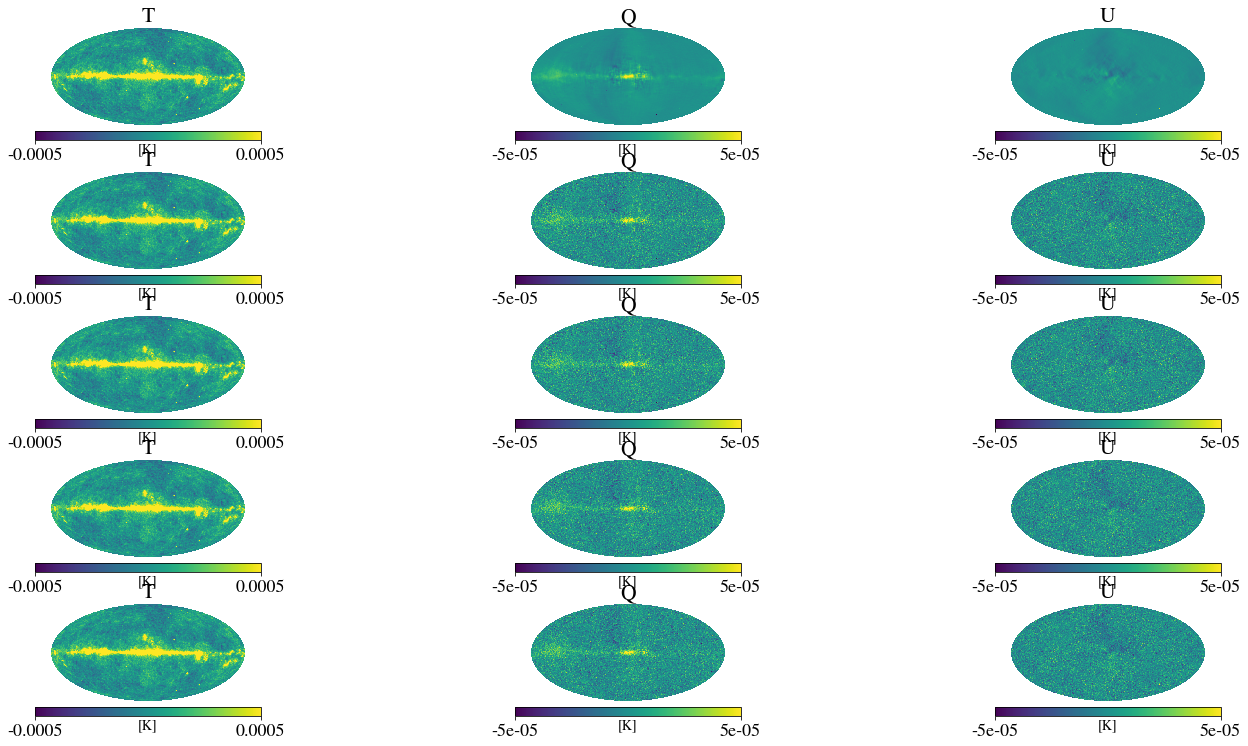

In [42]:
plt.figure(figsize=(20,10))
hp.mollview(m_input_coadd[0],                sub = (5,3,1),  title = 'T', unit = r'[K]',min=-5e-4,max=5e-4)
hp.mollview(m_input_coadd[1],                sub = (5,3,2),  title = 'Q', unit = r'[K]',min=-5e-5,max=5e-5)
hp.mollview(m_input_coadd[2],                sub = (5,3,3),  title = 'U', unit = r'[K]',min=-5e-5,max=5e-5)
hp.mollview(m_binned_cmb_fg_wn_1f_100mHz[0], sub = (5,3,4),  title = 'T', unit = r'[K]',min=-5e-4,max=5e-4)
hp.mollview(m_binned_cmb_fg_wn_1f_100mHz[1], sub = (5,3,5),  title = 'Q', unit = r'[K]',min=-5e-5,max=5e-5)
hp.mollview(m_binned_cmb_fg_wn_1f_100mHz[2], sub = (5,3,6),  title = 'U', unit = r'[K]',min=-5e-5,max=5e-5)
hp.mollview(m_destr_cmb_fg_wn_1f_100mHz[0],  sub = (5,3,7),  title = 'T', unit = r'[K]',min=-5e-4,max=5e-4)
hp.mollview(m_destr_cmb_fg_wn_1f_100mHz[1],  sub = (5,3,8),  title = 'Q', unit = r'[K]',min=-5e-5,max=5e-5)
hp.mollview(m_destr_cmb_fg_wn_1f_100mHz[2],  sub = (5,3,9),  title = 'U', unit = r'[K]',min=-5e-5,max=5e-5)
hp.mollview(m_binned_cmb_fg_wn_1f_30mHz[0],  sub = (5,3,10), title = 'T', unit = r'[K]',min=-5e-4,max=5e-4)
hp.mollview(m_binned_cmb_fg_wn_1f_30mHz[1],  sub = (5,3,11), title = 'Q', unit = r'[K]',min=-5e-5,max=5e-5)
hp.mollview(m_binned_cmb_fg_wn_1f_30mHz[2],  sub = (5,3,12), title = 'U', unit = r'[K]',min=-5e-5,max=5e-5)
hp.mollview(m_destr_cmb_fg_wn_1f_30mHz[0],   sub = (5,3,13), title = 'T', unit = r'[K]',min=-5e-4,max=5e-4)
hp.mollview(m_destr_cmb_fg_wn_1f_30mHz[1],   sub = (5,3,14), title = 'Q', unit = r'[K]',min=-5e-5,max=5e-5)
hp.mollview(m_destr_cmb_fg_wn_1f_30mHz[2],   sub = (5,3,15), title = 'U', unit = r'[K]',min=-5e-5,max=5e-5)

## maps differences

In [44]:
#TODO

## spectra: input vs output

f_sky:  0.7128499348958334


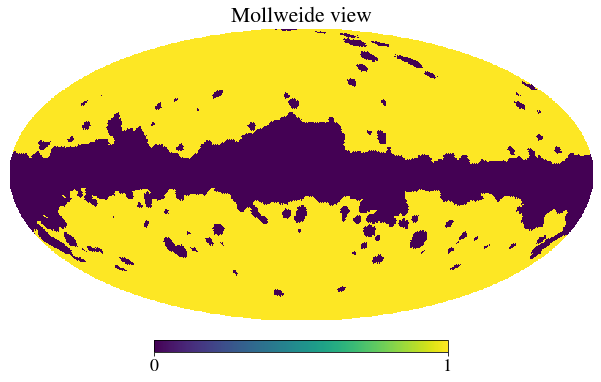

In [11]:
mask_temp = hp.read_map(mask_path)
mask = hp.ud_grade(mask_temp,512)
hp.mollview(mask)
print('f_sky: ',np.count_nonzero(mask)/hp.nside2npix(512))

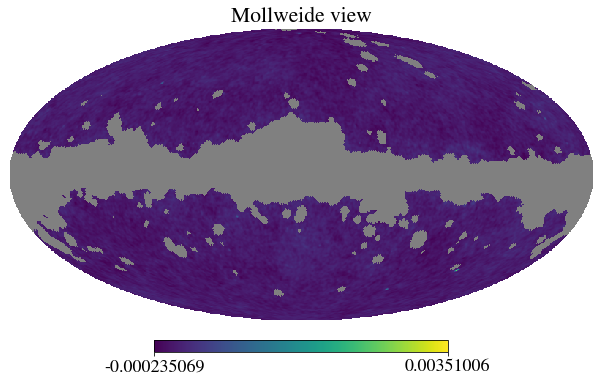

In [45]:
def masking(m, mask):
    m_masked = np.zeros_like(m)
    for field in range(3):
        m_masked[field] = np.where(mask,m[field],hp.UNSEEN)
    return m_masked

m_input_coadd_masked                = masking(m_input_coadd,mask)
m_binned_cmb_fg_wn_masked           = masking(m_binned_cmb_fg_wn,mask)
m_binned_cmb_fg_wn_1f_100mHz_masked = masking(m_binned_cmb_fg_wn_1f_100mHz,mask)
m_destr_cmb_fg_wn_1f_100mHz_masked  = masking(m_destr_cmb_fg_wn_1f_100mHz,mask)
m_binned_cmb_fg_wn_1f_30mHz_masked  = masking(m_binned_cmb_fg_wn_1f_30mHz,mask)
m_destr_cmb_fg_wn_1f_30mHz_masked   = masking(m_destr_cmb_fg_wn_1f_30mHz,mask)

hp.mollview(m_input_coadd_masked[0])

In [46]:
spectra_input_masked                                = hp.anafast(m_input_coadd_masked,               lmax=lmax,pol=True)

spectra_output_binned_cmb_fg_wn_masked              = hp.anafast(m_binned_cmb_fg_wn_masked,lmax=lmax,pol=True)

spectra_output_binned_cmb_fg_wn_1f_100mHz_masked    = hp.anafast(m_binned_cmb_fg_wn_1f_100mHz_masked,lmax=lmax,pol=True)
spectra_output_destriped_cmb_fg_wn_1f_100mHz_masked = hp.anafast(m_destr_cmb_fg_wn_1f_100mHz_masked, lmax=lmax,pol=True)
spectra_output_binned_cmb_fg_wn_1f_30mHz_masked     = hp.anafast(m_binned_cmb_fg_wn_1f_30mHz_masked, lmax=lmax,pol=True)
spectra_output_destriped_cmb_fg_wn_1f_30mHz_masked  = hp.anafast(m_destr_cmb_fg_wn_1f_30mHz_masked,  lmax=lmax,pol=True)

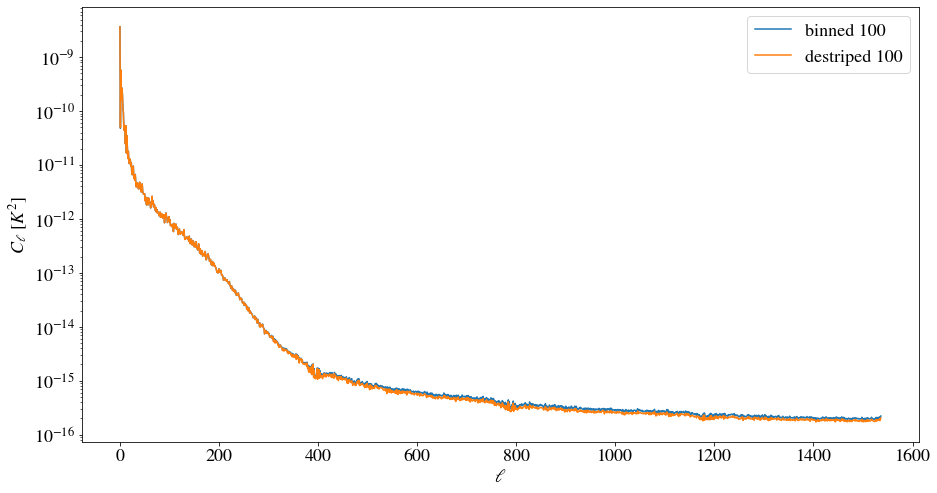

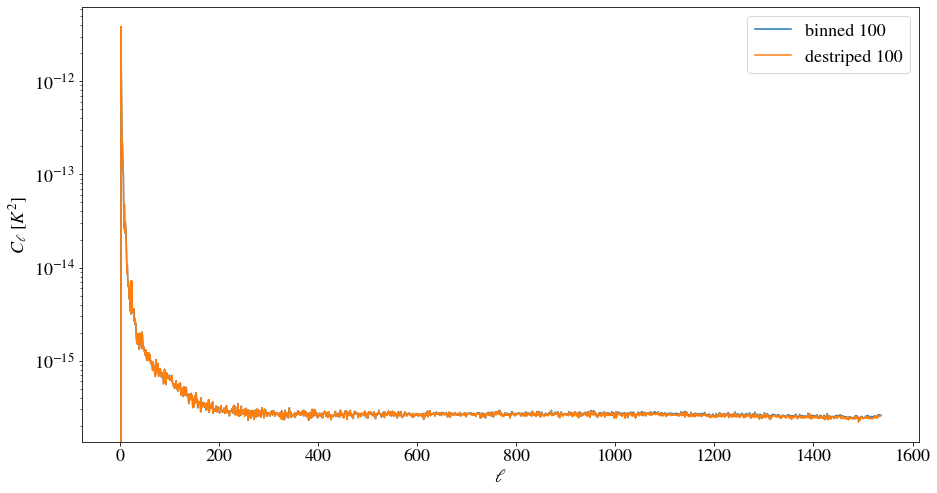

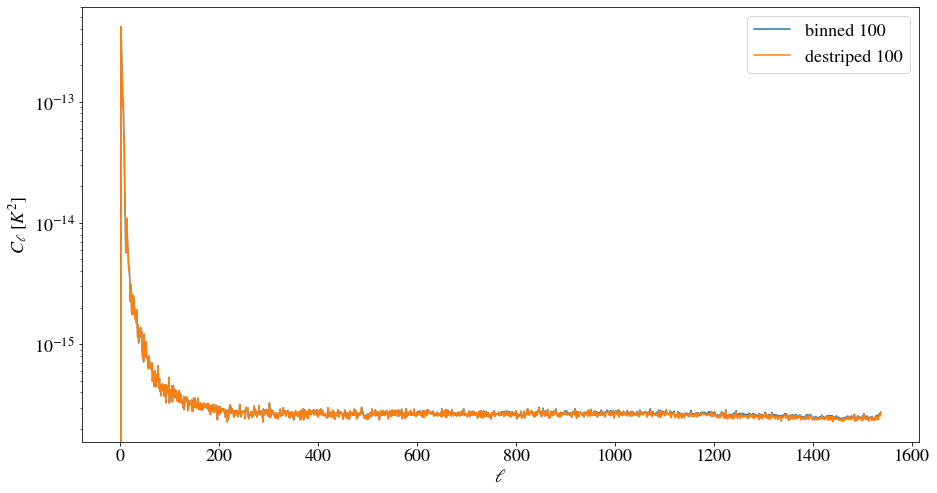

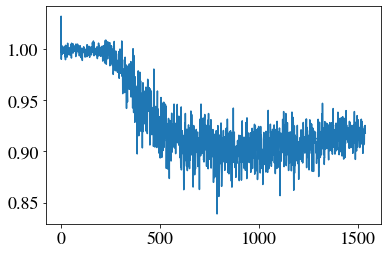

In [56]:
for field in range(3):
    plt.figure(figsize=(15,8))
    #plt.plot(l,spectra_input_masked[field],label='input')
    #plt.plot(l,spectra_output_binned_cmb_fg_wn_masked[field],label='binned wn')
    plt.plot(l,spectra_output_binned_cmb_fg_wn_1f_100mHz_masked[field],   label='binned 100')
    #plt.plot(l,spectra_output_binned_cmb_fg_wn_1f_30mHz_masked[field],    label='binned 30')
    plt.plot(l,spectra_output_destriped_cmb_fg_wn_1f_100mHz_masked[field],label='destriped 100')
    #plt.plot(l,spectra_output_destriped_cmb_fg_wn_1f_30mHz_masked[field], label='destriped 30')
    #plt.title('TT')
    plt.xlabel('$\ell$')
    plt.ylabel('$C_\ell\ [K^2]$')
    plt.semilogy()
    #plt.loglog()
    plt.legend()

#plt.figure(figsize=(15,8))
#plt.plot(l,spectra_output[0]/spectra_input[0])
#plt.title('TT ratio')
#plt.xlabel('$\ell$')
#plt.show()
plt.figure()
plt.plot(spectra_output_destriped_cmb_fg_wn_1f_100mHz_masked[0]/spectra_output_binned_cmb_fg_wn_1f_100mHz_masked[0])

## spectra binned make_bin_map vs binned destriped

In [48]:
m_destr_binned_cmb_fg_wn_1f_100mHz = hp.read_map(output_dir+'madam_cmb_fg_wn_1f_100mHz/maps/binned.fits',field=[0,1,2])
m_destr_binned_wn_1f_100mHz = hp.read_map(output_dir+'madam_wn_1f_100mHz/maps/binned.fits',field=[0,1,2])

m_destr_binned_cmb_fg_wn_1f_30mHz = hp.read_map(output_dir+'madam_cmb_fg_wn_1f_30mHz/maps/binned.fits',field=[0,1,2])
m_destr_binned_wn_1f_30mHz = hp.read_map(output_dir+'madam_wn_1f_30mHz/maps/binned.fits',field=[0,1,2])

In [49]:
m_destr_binned_cmb_fg_wn_1f_100mHz_masked  = masking(m_destr_binned_cmb_fg_wn_1f_100mHz,mask)
m_destr_binned_cmb_fg_wn_1f_30mHz_masked   = masking(m_destr_binned_cmb_fg_wn_1f_30mHz,mask)

m_destr_binned_wn_1f_100mHz_masked  = masking(m_destr_binned_wn_1f_100mHz,mask)
m_destr_binned_wn_1f_30mHz_masked   = masking(m_destr_binned_wn_1f_30mHz,mask)

In [50]:
spectra_output_destriped_binned_cmb_fg_wn_1f_100mHz_masked = hp.anafast(m_destr_binned_cmb_fg_wn_1f_100mHz_masked, lmax=lmax,pol=True)
spectra_output_destriped_binned_cmb_fg_wn_1f_30mHz_masked  = hp.anafast(m_destr_binned_cmb_fg_wn_1f_30mHz_masked,  lmax=lmax,pol=True)

spectra_output_destriped_binned_wn_1f_100mHz_masked = hp.anafast(m_destr_binned_wn_1f_100mHz_masked, lmax=lmax,pol=True)
spectra_output_destriped_binned_wn_1f_30mHz_masked  = hp.anafast(m_destr_binned_wn_1f_30mHz_masked,  lmax=lmax,pol=True)

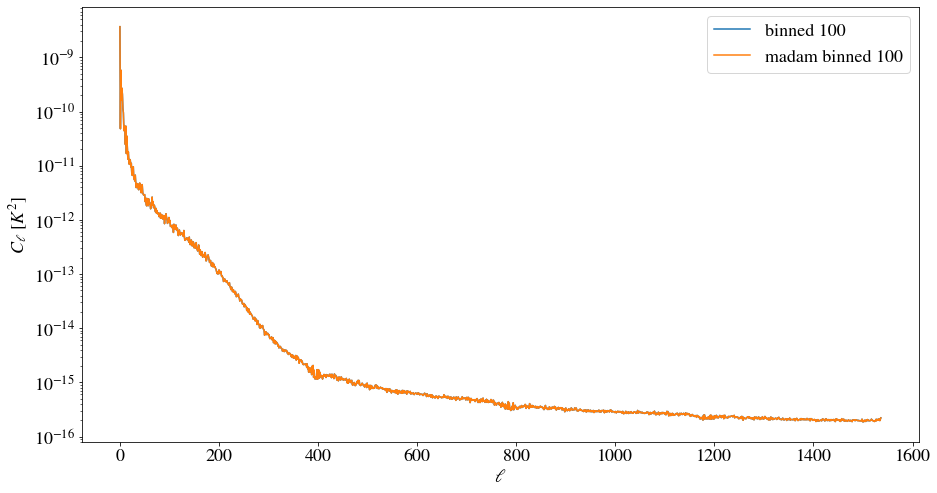

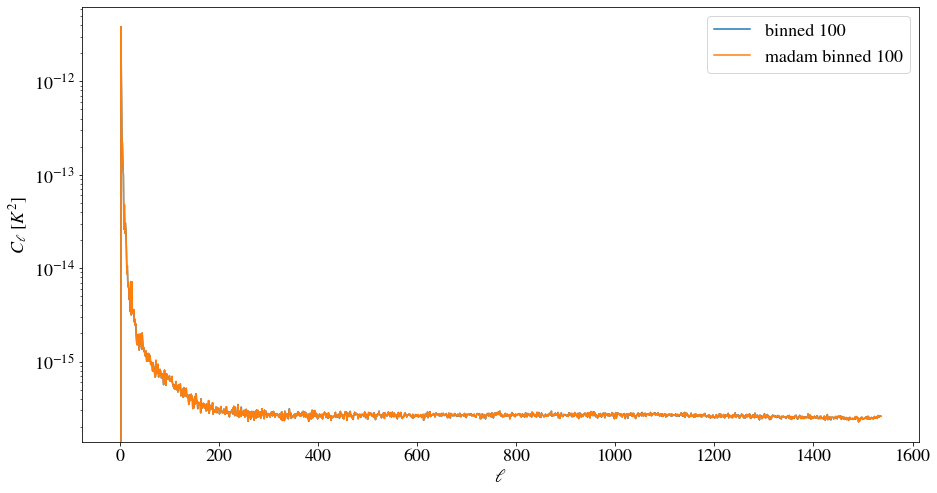

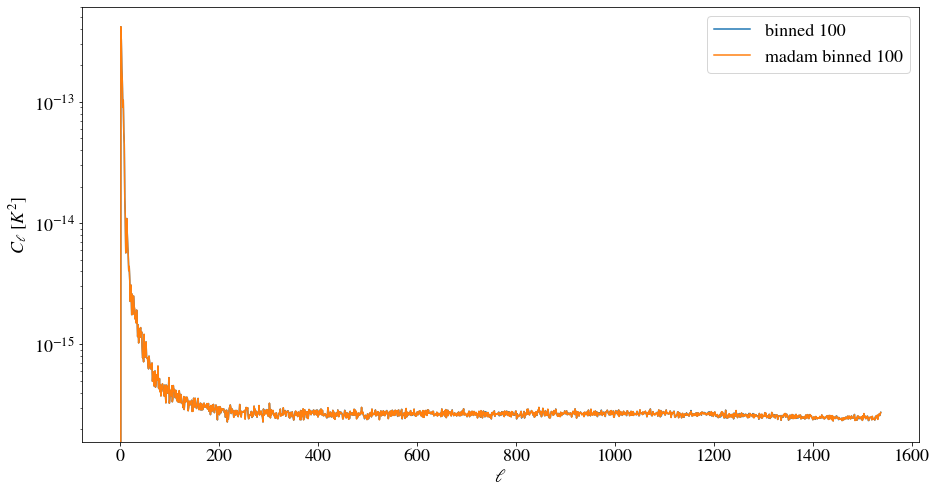

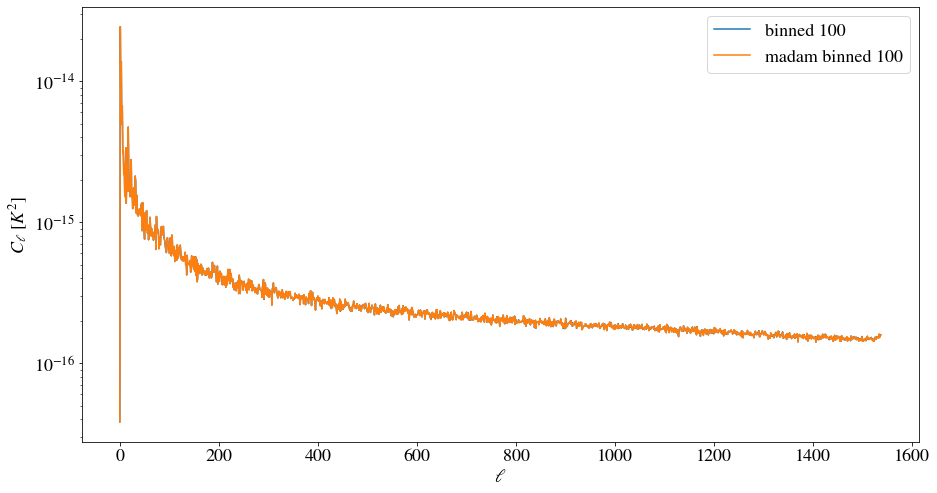

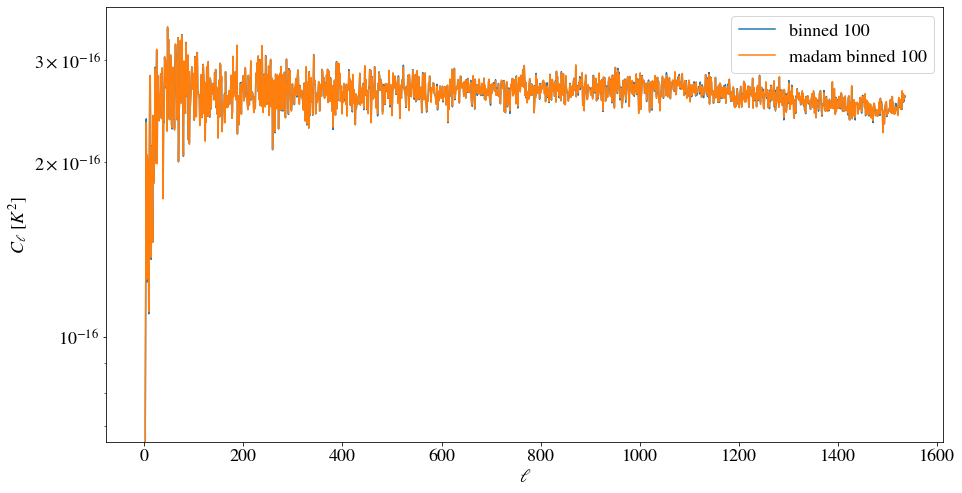

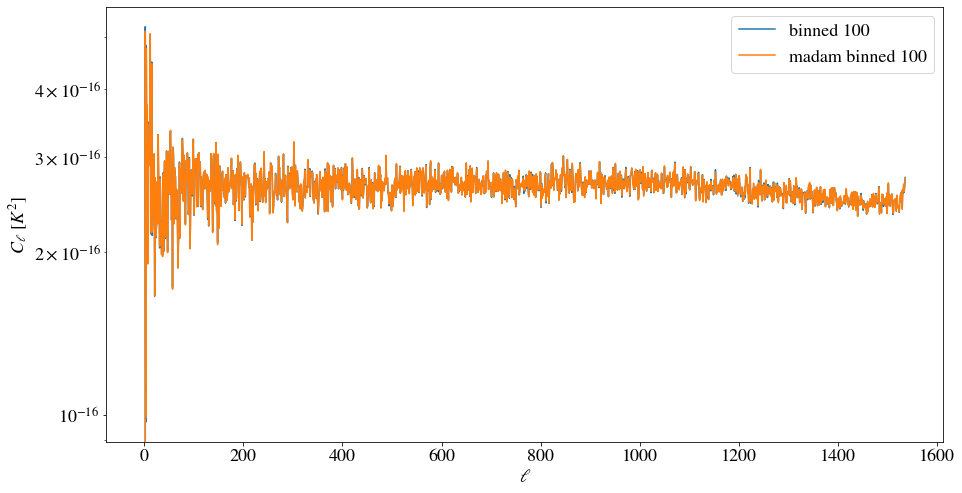

In [59]:
for field in range(3):
    plt.figure(figsize=(15,8))
    plt.plot(l,spectra_output_binned_cmb_fg_wn_1f_100mHz_masked[field],          label='binned 100')
    plt.plot(l,spectra_output_destriped_binned_cmb_fg_wn_1f_100mHz_masked[field],label='madam binned 100')
    plt.xlabel('$\ell$')
    plt.ylabel('$C_\ell\ [K^2]$')
    plt.semilogy()
    #plt.loglog()
    plt.legend()
    
for field in range(3):
    plt.figure(figsize=(15,8))
    plt.plot(l,spectra_output_binned_wn_1f_100mHz_masked[field],          label='binned 100')
    plt.plot(l,spectra_output_destriped_binned_wn_1f_100mHz_masked[field],label='madam binned 100')
    plt.xlabel('$\ell$')
    plt.ylabel('$C_\ell\ [K^2]$')
    plt.semilogy()
    #plt.loglog()
    plt.legend()

## spectra binned make_bin_map vs binned destriped (only cmb)

In [14]:
output_dir_4det = rootdir+'litebird/e2e_ns'+str(nside)+'/sim0000/detectors_'+instrument+'_'+channel+'_T+B_4det_only_cmb'

m_destr_binned_cmb = hp.read_map(output_dir_4det+'/madam_cmb/maps/binned.fits',field=[0,1,2])
m_binned_cmb       = hp.read_map(output_dir_4det+'maps/LB_LFT_50_binned_cmb_365d_0000.fits',field=[0,1,2])


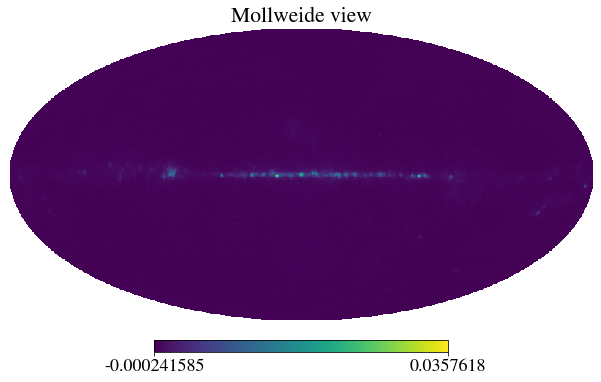

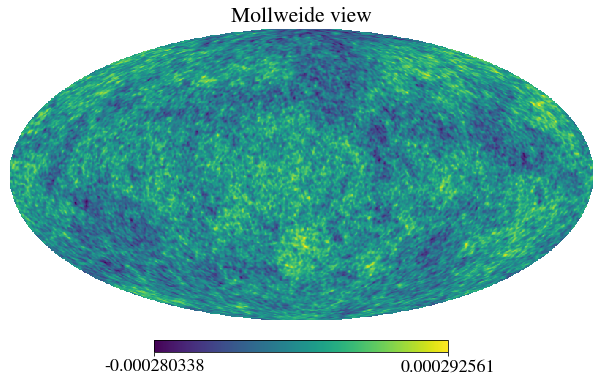

In [26]:
hp.mollview(m_destr_binned_cmb[0])
hp.mollview(m_binned_cmb[0])

In [19]:
spectra_output_destriped_binned_cmb = hp.anafast(m_destr_binned_cmb, lmax=lmax,pol=True)
spectra_output_binned_cmb           = hp.anafast(m_binned_cmb,       lmax=lmax,pol=True)

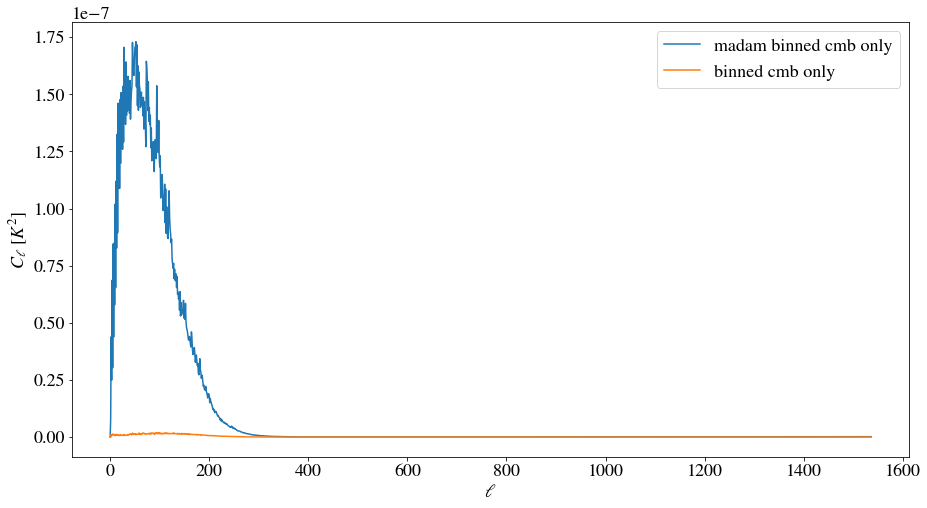

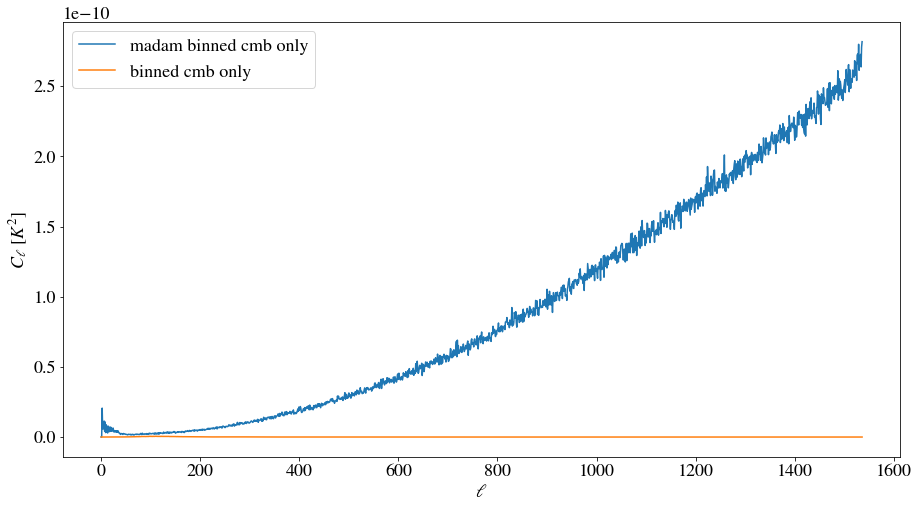

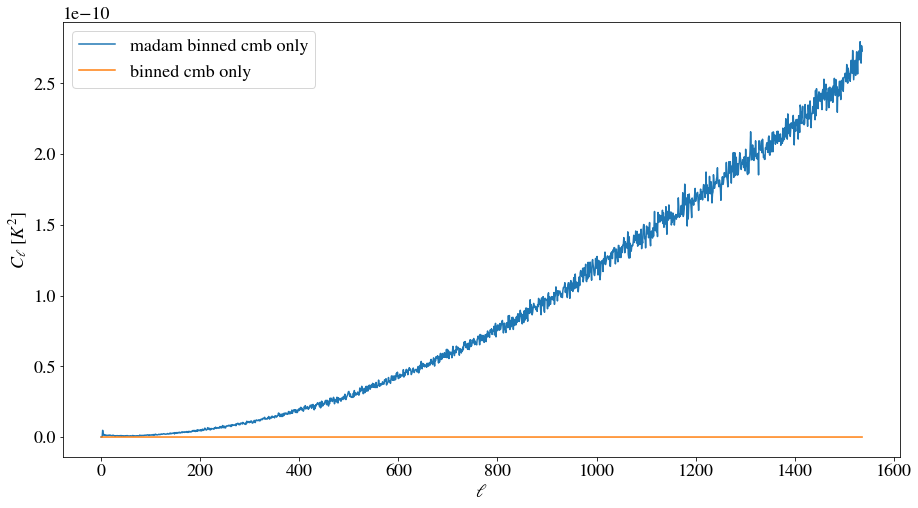

In [24]:
for field in range(3):
    plt.figure(figsize=(15,8))
    plt.plot(l,ll*spectra_output_destriped_binned_cmb[field],label='madam binned cmb only')
    plt.plot(l,ll*spectra_output_binned_cmb[field],          label='binned cmb only')
    plt.xlabel('$\ell$')
    plt.ylabel('$C_\ell\ [K^2]$')
    #plt.semilogy()
    #plt.loglog()
    plt.legend()

## spectra binned make_bin_map vs binned destriped (only fg)

In [28]:
output_dir_4det = rootdir+'litebird/e2e_ns'+str(nside)+'/sim0000/detectors_'+instrument+'_'+channel+'_T+B_4det_only_fg/'

m_destr_binned_fg = hp.read_map(output_dir_4det+'madam_fg/maps/binned.fits',field=[0,1,2])
m_binned_fg       = hp.read_map(output_dir_4det+'maps/LB_LFT_50_binned_fg_365d_0000.fits',field=[0,1,2])


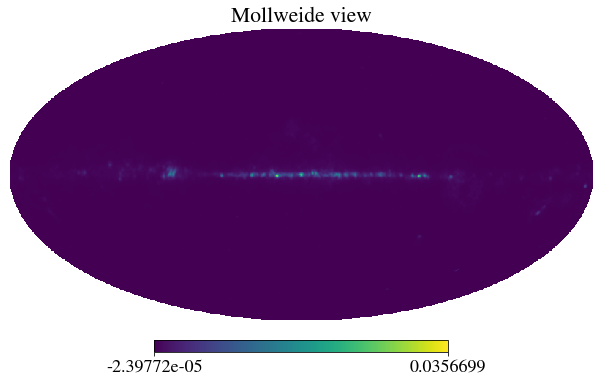

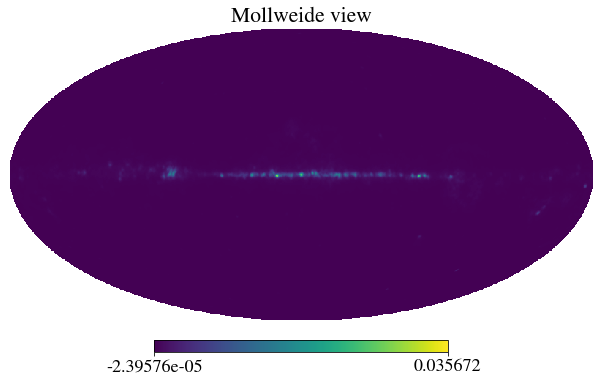

In [29]:
hp.mollview(m_destr_binned_fg[0])
hp.mollview(m_binned_fg[0])

In [30]:
spectra_output_destriped_binned_fg = hp.anafast(m_destr_binned_fg,lmax=lmax,pol=True)
spectra_output_binned_fg           = hp.anafast(m_binned_fg,      lmax=lmax,pol=True)

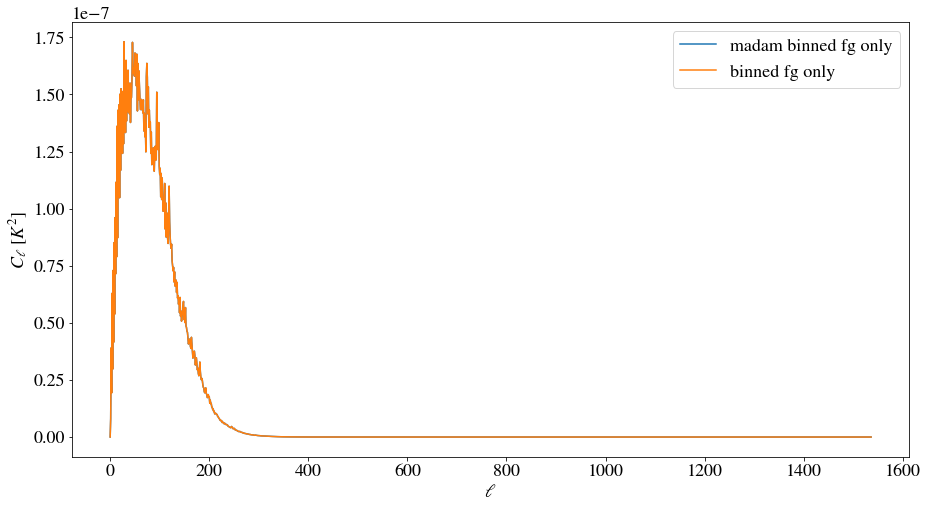

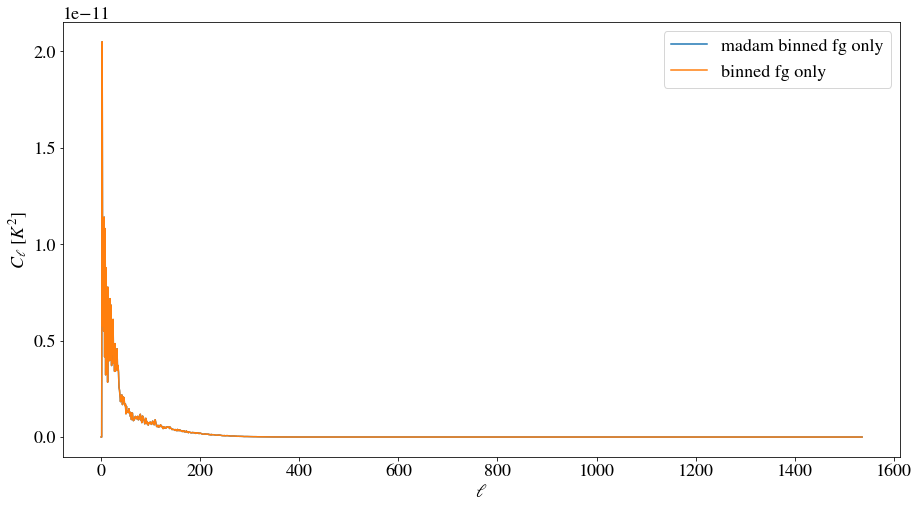

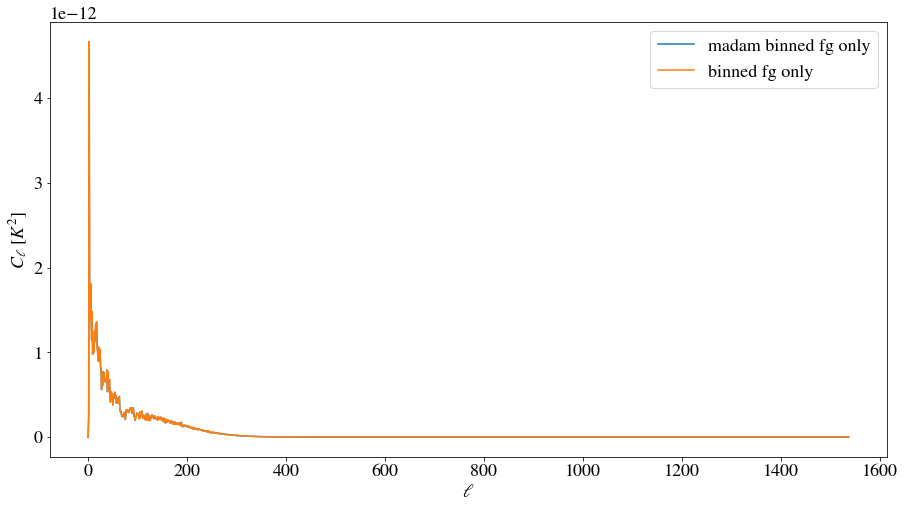

In [32]:
for field in range(3):
    plt.figure(figsize=(15,8))
    plt.plot(l,ll*spectra_output_destriped_binned_fg[field],label='madam binned fg only')
    plt.plot(l,ll*spectra_output_binned_fg[field],          label='binned fg only')
    plt.xlabel('$\ell$')
    plt.ylabel('$C_\ell\ [K^2]$')
    #plt.semilogy()
    #plt.loglog()
    plt.legend()

## spectra binned vs destriped (noise only)

#### mask with healpy

In [57]:
m_binned_wn_1f_100mHz_masked = masking(m_binned_wn_1f_100mHz,mask)
m_destr_wn_1f_100mHz_masked  = masking(m_destr_wn_1f_100mHz,mask)
m_binned_wn_1f_30mHz_masked  = masking(m_binned_wn_1f_30mHz,mask)
m_destr_wn_1f_30mHz_masked   = masking(m_destr_wn_1f_30mHz,mask)

spectra_output_binned_wn_1f_100mHz_masked    = hp.anafast(m_binned_wn_1f_100mHz_masked,lmax=lmax,pol=True)
spectra_output_destriped_wn_1f_100mHz_masked = hp.anafast(m_destr_wn_1f_100mHz_masked, lmax=lmax,pol=True)
spectra_output_binned_wn_1f_30mHz_masked     = hp.anafast(m_binned_wn_1f_30mHz_masked, lmax=lmax,pol=True)
spectra_output_destriped_wn_1f_30mHz_masked  = hp.anafast(m_destr_wn_1f_30mHz_masked,  lmax=lmax,pol=True)

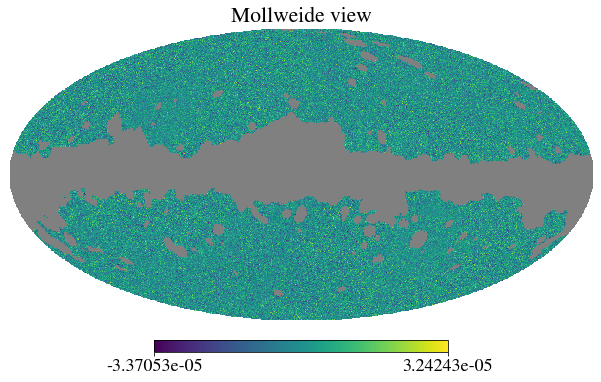

In [58]:
m_diff_binned_100 = np.zeros_like(m_input_coadd_masked)
m_diff_binned_30  = np.zeros_like(m_input_coadd_masked)
m_diff_destr_100  = np.zeros_like(m_input_coadd_masked)
m_diff_destr_30   = np.zeros_like(m_input_coadd_masked)

for field in range(3):
    m_diff_binned_100[field] = np.where(mask,m_binned_cmb_fg_wn_1f_100mHz_masked[field] - m_input_coadd_masked[field],hp.UNSEEN)
    m_diff_binned_30[field]  = np.where(mask,m_binned_cmb_fg_wn_1f_30mHz_masked[field]  - m_input_coadd_masked[field],hp.UNSEEN)
    m_diff_destr_100[field]  = np.where(mask,m_destr_cmb_fg_wn_1f_100mHz_masked[field]  - m_input_coadd_masked[field],hp.UNSEEN)
    m_diff_destr_30[field]   = np.where(mask,m_destr_cmb_fg_wn_1f_30mHz_masked[field]   - m_input_coadd_masked[field],hp.UNSEEN)
hp.mollview(m_diff_destr_100[0])

spectra_binned_cmb_fg_wn_1f_100mHz_minus_coadd_masked = hp.anafast(m_diff_binned_100,lmax=lmax)
spectra_binned_cmb_fg_wn_1f_30mHz_minus_coadd_masked  = hp.anafast(m_diff_binned_30, lmax=lmax)
spectra_destr_cmb_fg_wn_1f_100mHz_minus_coadd_masked  = hp.anafast(m_diff_destr_100, lmax=lmax)
spectra_destr_cmb_fg_wn_1f_30mHz_minus_coadd_masked   = hp.anafast(m_diff_destr_30,  lmax=lmax)

f_knee = 100
********************* 0 *********************


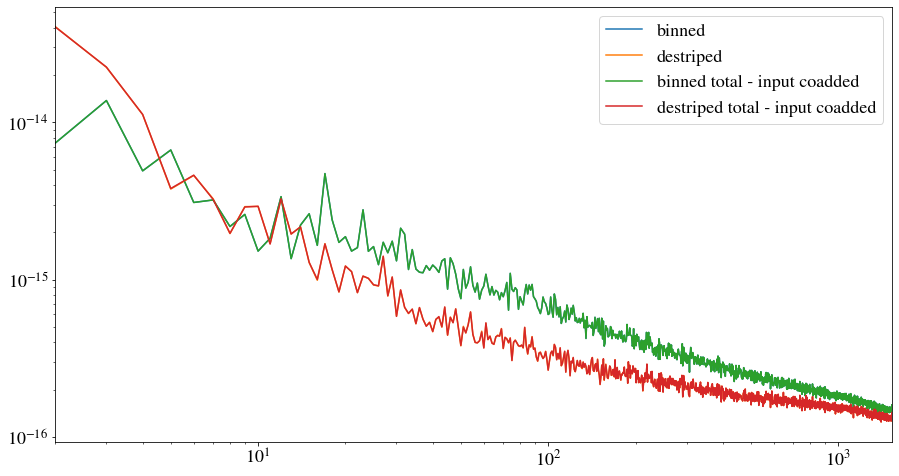

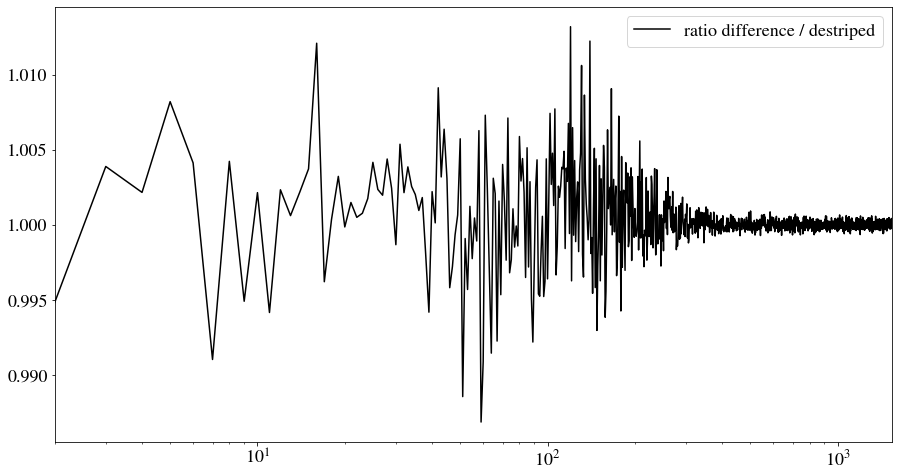

average ratio:  1.0001460285253594


********************* 1 *********************


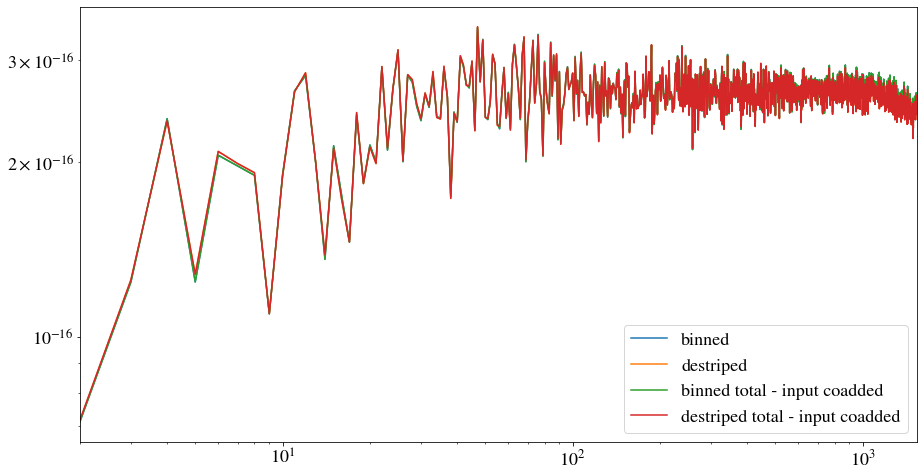

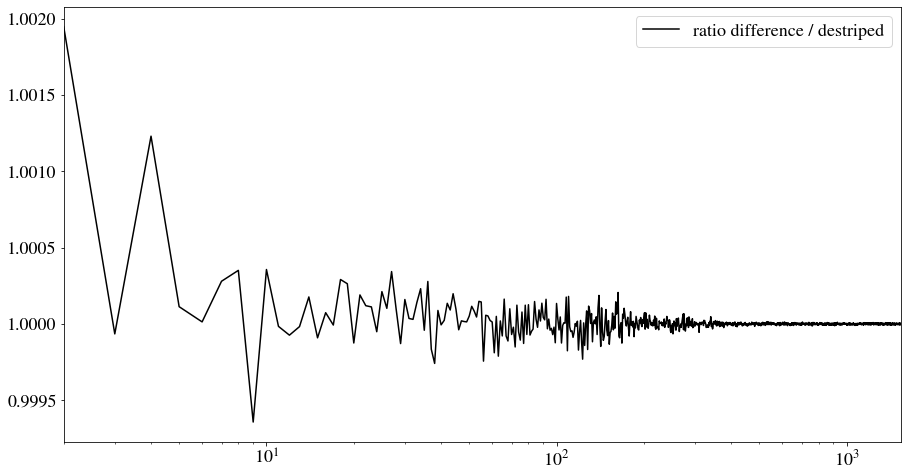

average ratio:  1.0000040098658847


********************* 2 *********************


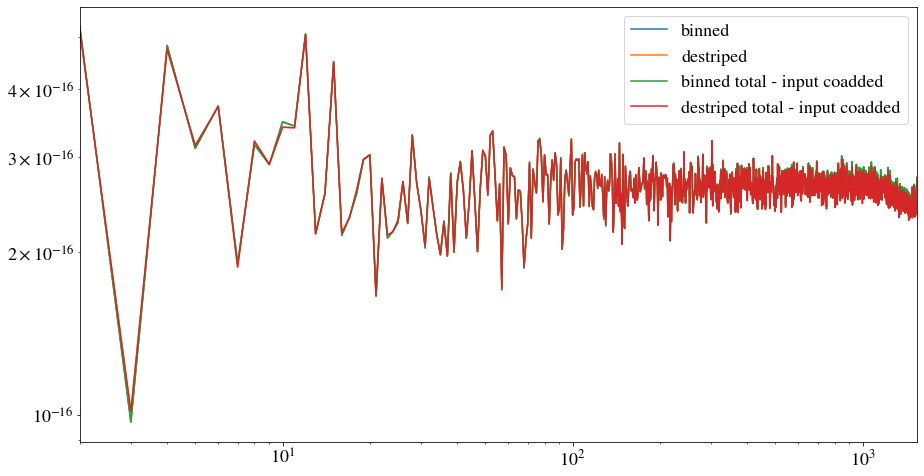

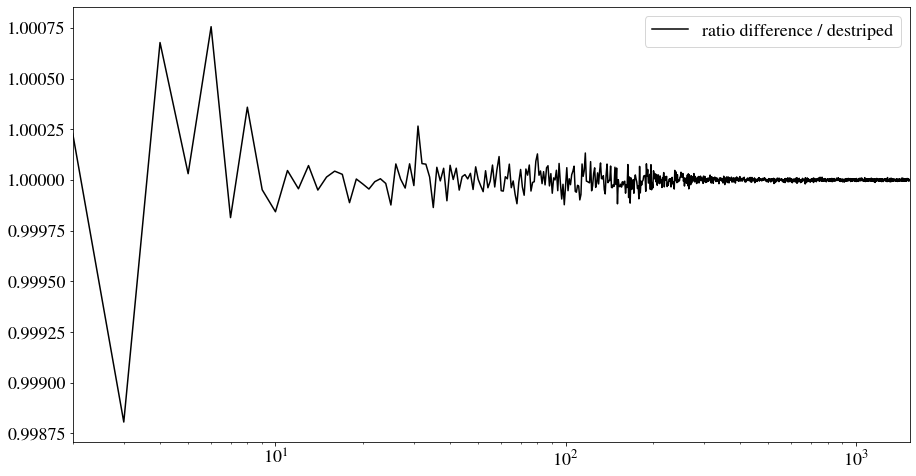

average ratio:  1.000000331513001




In [65]:
print('f_knee = 100')
for field in range(3):
    print('*********************',field,'*********************')
    
    plt.figure(figsize=(15,8))
    plt.plot(l[2:],spectra_output_binned_wn_1f_100mHz_masked[field][2:],            label='binned')
    plt.plot(l[2:],spectra_output_destriped_wn_1f_100mHz_masked[field][2:],         label='destriped')
    plt.plot(l[2:],spectra_binned_cmb_fg_wn_1f_100mHz_minus_coadd_masked[field][2:],label='binned total - input coadded')
    plt.plot(l[2:],spectra_destr_cmb_fg_wn_1f_100mHz_minus_coadd_masked[field][2:], label='destriped total - input coadded')
    plt.xlim(2,lmax)
    #plt.ylim(1e-17,1e-13)
    plt.loglog()
    plt.legend()
    plt.show()

    plt.figure(figsize=(15,8))
    plt.plot(l[2:],spectra_destr_cmb_fg_wn_1f_100mHz_minus_coadd_masked[field][2:]/spectra_output_destriped_wn_1f_100mHz_masked[field][2:],
             label='ratio difference / destriped',color='black')
    plt.xlim(2,lmax)
    plt.xscale('log')
    plt.legend()
    plt.show()
    print('average ratio: ', np.average(spectra_destr_cmb_fg_wn_1f_100mHz_minus_coadd_masked[field][2:]/spectra_output_destriped_wn_1f_100mHz_masked[field][2:]))
    print('')
    print('')

f_knee = 30
********************* 0 *********************


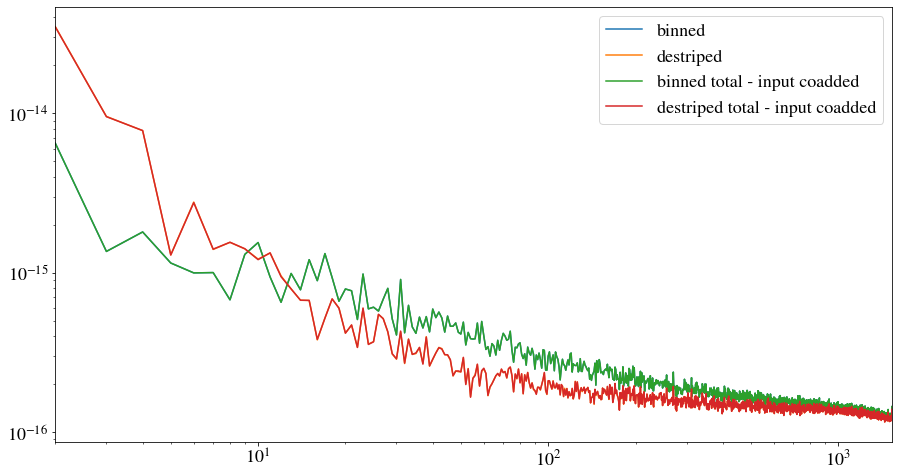

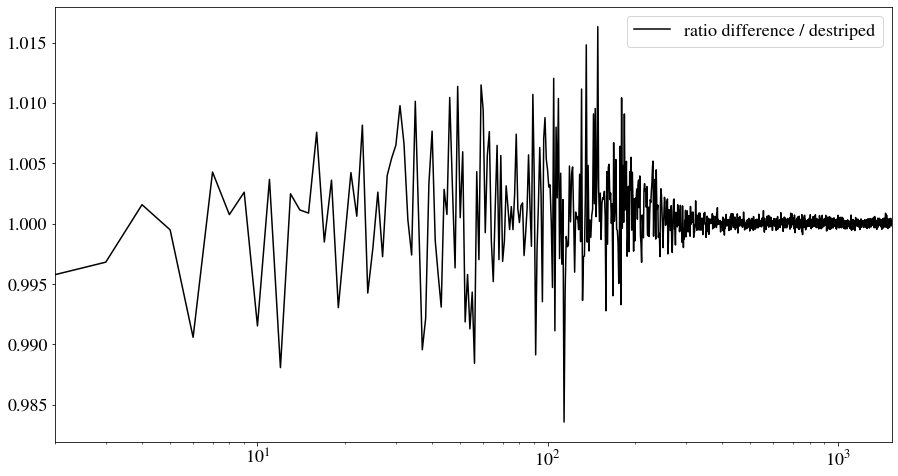

average ratio:  1.000236227616502


********************* 1 *********************


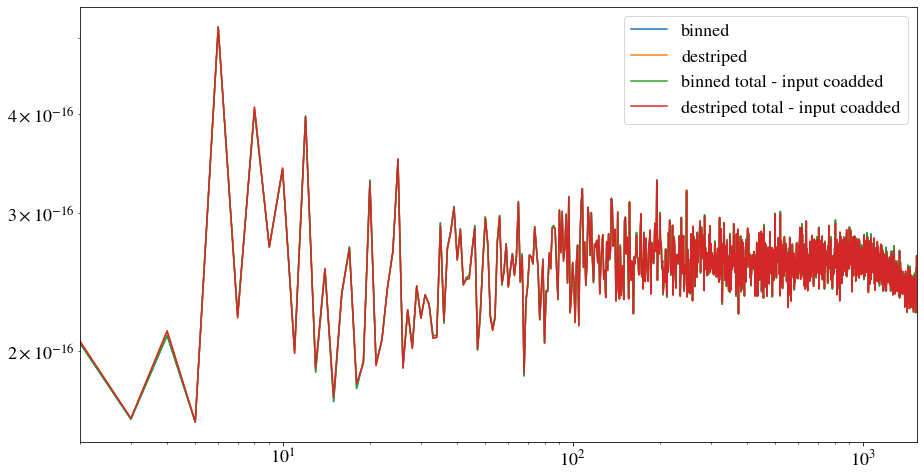

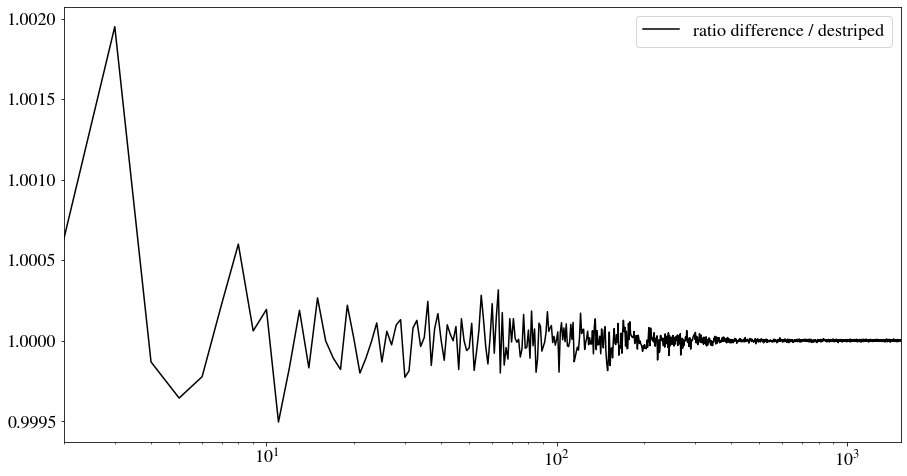

average ratio:  1.0000020655333883


********************* 2 *********************


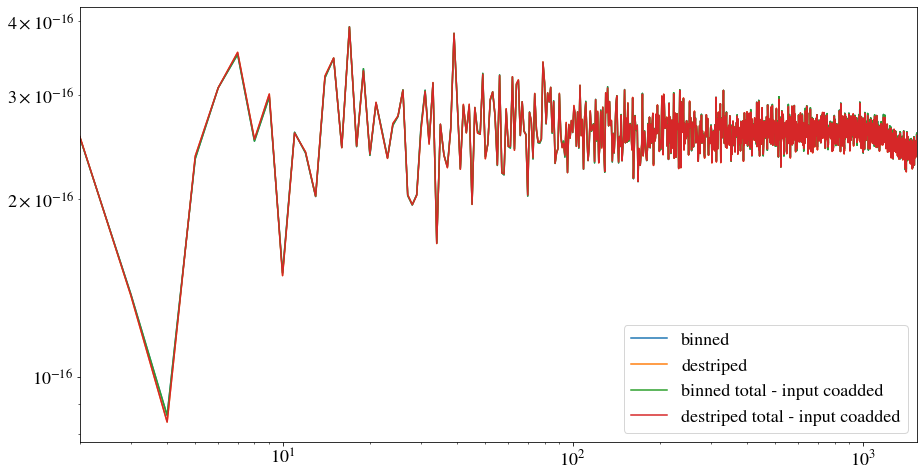

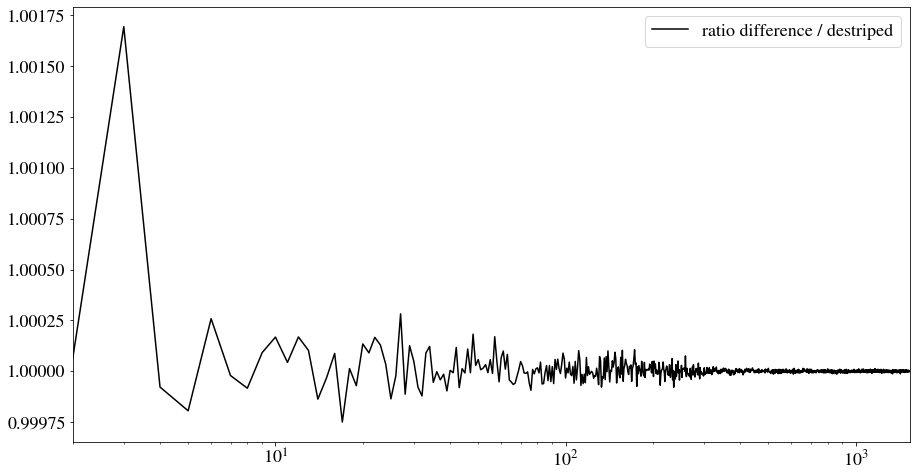

average ratio:  1.0000022940703974




In [61]:
print('f_knee = 30')
for field in range(3):
    print('*********************',field,'*********************')
    
    plt.figure(figsize=(15,8))
    plt.plot(l[2:],spectra_output_binned_wn_1f_30mHz_masked[field][2:],            label='binned')
    plt.plot(l[2:],spectra_output_destriped_wn_1f_30mHz_masked[field][2:],         label='destriped')
    plt.plot(l[2:],spectra_binned_cmb_fg_wn_1f_30mHz_minus_coadd_masked[field][2:],label='binned total - input coadded')
    plt.plot(l[2:],spectra_destr_cmb_fg_wn_1f_30mHz_minus_coadd_masked[field][2:], label='destriped total - input coadded')
    plt.xlim(2,lmax)
    #plt.ylim(1e-17,1e-13)
    plt.loglog()
    plt.legend()
    plt.show()

    plt.figure(figsize=(15,8))
    plt.plot(l[2:],spectra_destr_cmb_fg_wn_1f_30mHz_minus_coadd_masked[field][2:]/spectra_output_destriped_wn_1f_30mHz_masked[field][2:],
             label='ratio difference / destriped',color='black')
    plt.xlim(2,lmax)
    plt.xscale('log')
    plt.legend()
    plt.show()
    print('average ratio: ', np.average(spectra_destr_cmb_fg_wn_1f_30mHz_minus_coadd_masked[field][2:]/spectra_output_destriped_wn_1f_30mHz_masked[field][2:]))
    print('')
    print('')

#### mask with namaster

In [36]:
def spectra_from_namaster(m,mask):
    b = nmt.NmtBin.from_lmax_linear(lmax, 1, is_Dell=False)

    f0 = nmt.NmtField(mask,[m],lmax_sht=lmax)
    
    w00 = nmt.NmtWorkspace()
    w00.compute_coupling_matrix(f0, f0, b)
    
    cl_coupled_00 = nmt.compute_coupled_cell(f0, f0)
    
    return w00.decouple_cell(cl_coupled_00)

In [ ]:
#same results

### hit map

In [66]:
m_hit = hp.read_map(output_dir+'madam_cmb_fg_wn_1f_100mHz/maps/hits.fits',field=[0,1,2])

T 761.90185546875
Q 190.4754638671875
U 190.4754638671875


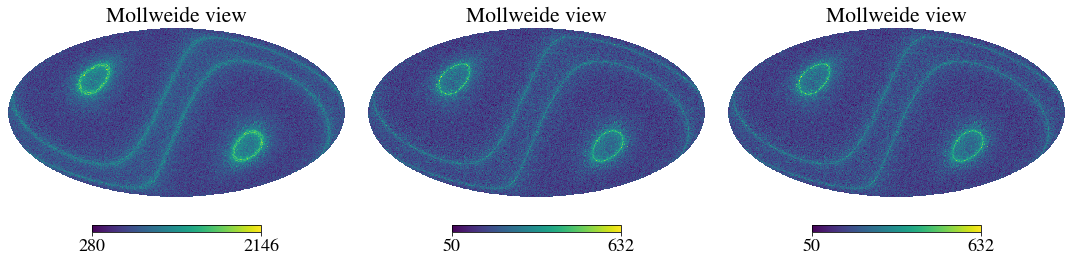

In [67]:
plt.figure(figsize=(15,8))
hp.mollview(m_hit[0], sub=131)
hp.mollview(m_hit[1], sub=132)
hp.mollview(m_hit[2], sub=133)
print('T',np.average(m_hit[0]))
print('Q',np.average(m_hit[1]))
print('U',np.average(m_hit[2]))

### input cmb and fg maps

In [39]:
m_input_cmb = hp.read_map(input_dir+'cmb/00/LB_LFT_50_lens_cmb_postPTEP20220609.fits',field=[0,1,2])

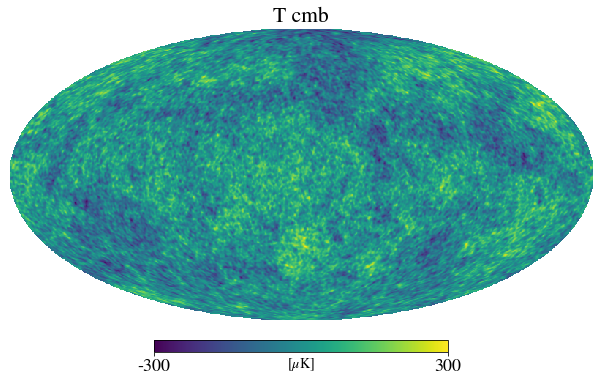

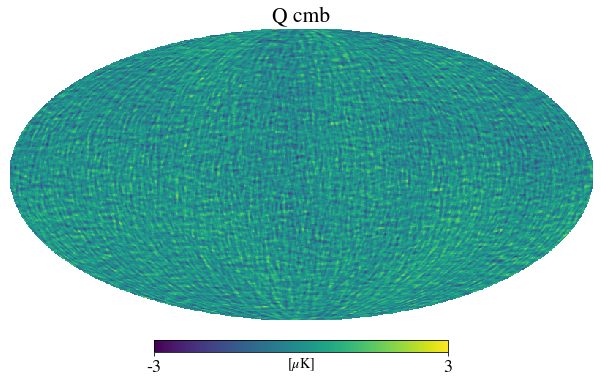

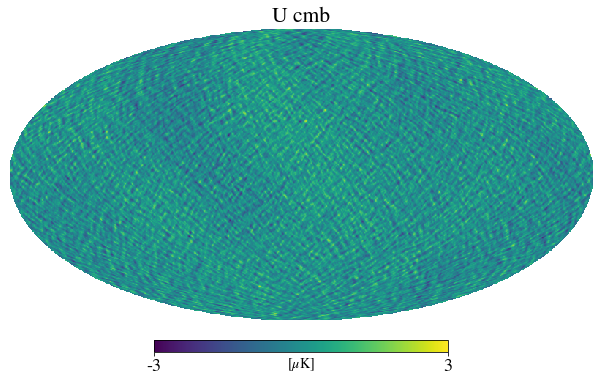

In [40]:
hp.mollview(m_input_cmb[0],title='T cmb',unit=r'[$\mu$K]',min=-300,max=300)
hp.mollview(m_input_cmb[1],title='Q cmb',unit=r'[$\mu$K]',min=-3,max=3)
hp.mollview(m_input_cmb[2],title='U cmb',unit=r'[$\mu$K]',min=-3,max=3)

In [41]:
m_input_fg = hp.read_map(input_dir+'all_fg/LB_LFT_50_all_fg_postPTEP20220609.fits',field=[0,1,2])

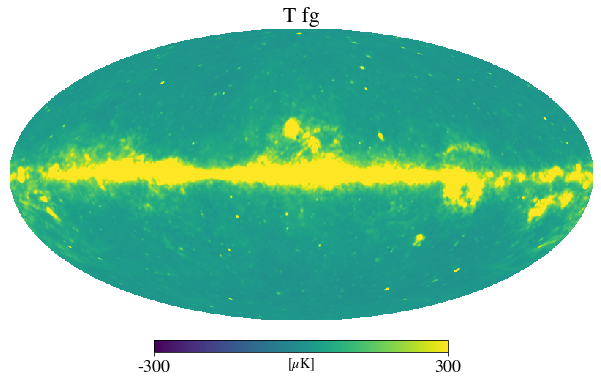

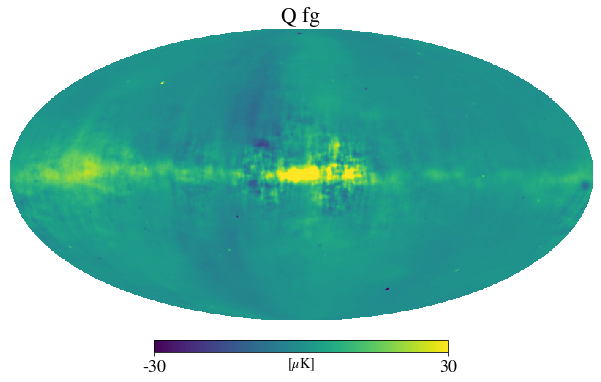

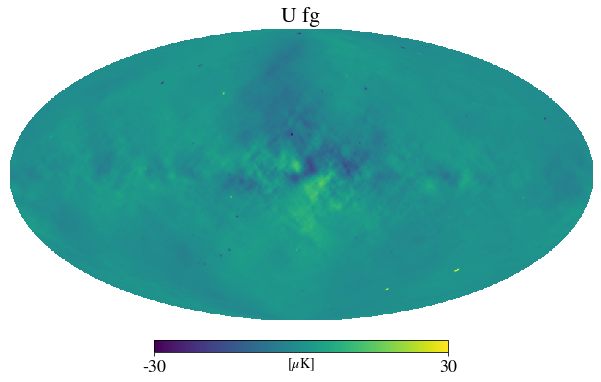

In [42]:
hp.mollview(m_input_fg[0],title='T fg',unit=r'[$\mu$K]',min=-300,max=300)
hp.mollview(m_input_fg[1],title='Q fg',unit=r'[$\mu$K]',min=-30,max=30)
hp.mollview(m_input_fg[2],title='U fg',unit=r'[$\mu$K]',min=-30,max=30)

### madam

In [45]:
from astropy.io import fits

hdul = fits.open(output_dir+'madam_cmb_fg_wn_1f_100mHz/tod_000_000_000_QA_050_B_00000.fits')


In [46]:
hdul.info()

Filename: /home/bortolami/Desktop/Universita/Dottorato/Ferrara Fisica/Programmi e Script/marconi_mounts/marconi_scratch/litebird/e2e_ns512/sim0000/detectors_LFT_L2-050_T+B_for_validation_multitod_fix209/madam_cmb_fg_wn_1f_100mHz/tod_000_000_000_QA_050_B_00000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  TOD           1 BinTableHDU     12   462334R x 1C   [E]   
  2  TOD_FG        1 BinTableHDU     12   462334R x 1C   [E]   
  3  TOD_WN_1F_100MHZ    1 BinTableHDU     12   462334R x 1C   [E]   
  4  TOD_WN_1F_30MHZ    1 BinTableHDU     12   462334R x 1C   [E]   


In [47]:
hdul[1]

In [48]:
hdr = hdul[1].header

In [49]:
for key in list(hdr.keys()):
    print(key)
    print(hdr[key])
    print('-----')

XTENSION
BINTABLE
-----
BITPIX
8
-----
NAXIS
2
-----
NAXIS1
4
-----
NAXIS2
462334
-----
PCOUNT
0
-----
GCOUNT
1
-----
TFIELDS
1
-----
TTYPE1
TOD
-----
TFORM1
E
-----
EXTNAME
TOD
-----
COMP
tod
-----


In [51]:
data = hdul[1].data
print(data.shape)
print(data)
print(data[42])

(462334,)
[( 1.14115195e-04,) ( 1.14228154e-04,) ( 1.14508563e-04,) ...
 (-4.30511973e-05,) (-4.28699459e-05,) (-4.22379308e-05,)]
(0.000132198)


In [53]:
from astropy.io import fits

for rank in range(0,10):
    print(rank)
    hdul = fits.open(output_dir+'/madam_cmb_fg_wn_1f_100mHz/tod_000_000_000_QA_050_B_'+str(rank).zfill(5)+'.fits')
    data = hdul[1].data
    print(data.shape)
    print(data)
    print('---------------------------------')

0
(462334,)
[( 1.14115195e-04,) ( 1.14228154e-04,) ( 1.14508563e-04,) ...
 (-4.30511973e-05,) (-4.28699459e-05,) (-4.22379308e-05,)]
---------------------------------
1
(462334,)
[(-4.1751220e-05,) (-3.7802954e-05,) (-3.8530485e-05,) ...
 (-3.8618356e-05,) (-3.9111092e-05,) (-3.8591632e-05,)]
---------------------------------
2
(462334,)
[(-3.7550239e-05,) (-3.5456618e-05,) (-3.5927536e-05,) ...
 (-4.8959293e-05,) (-4.8878359e-05,) (-4.8607591e-05,)]
---------------------------------
3
(462334,)
[(-5.3097934e-05,) (-5.3061729e-05,) (-5.3177075e-05,) ...
 (-2.0951882e-05,) (-1.5371188e-05,) (-1.4848050e-05,)]
---------------------------------
4
(462334,)
[(-1.41355495e-05,) (-1.39075082e-05,) (-1.43795933e-05,) ...
 (-1.91814852e-05,) (-1.91875260e-05,) (-1.92578937e-05,)]
---------------------------------
5
(462334,)
[(-1.6129512e-05,) (-1.6128539e-05,) (-1.5976544e-05,) ...
 ( 4.0655090e-05,) ( 4.0742969e-05,) ( 4.0606737e-05,)]
---------------------------------
6
(462334,)
[( 4.03749

### Change coordinates (if necessary, not accurate)

In [23]:
def change_coord(m, coord):
    """ Change coordinates of a HEALPIX map

    Parameters
    ----------
    m : map or array of maps
      map(s) to be rotated
    coord : sequence of two character
      First character is the coordinate system of m, second character
      is the coordinate system of the output map. As in HEALPIX, allowed
      coordinate systems are 'G' (galactic), 'E' (ecliptic) or 'C' (equatorial)

    Example
    -------
    The following rotate m from galactic to equatorial coordinates.
    Notice that m can contain both temperature and polarization.
    >>>> change_coord(m, ['G', 'C'])
    """
    # Basic HEALPix parameters
    npix = m.shape[-1]
    nside = hp.npix2nside(npix)
    ang = hp.pix2ang(nside, np.arange(npix))

    # Select the coordinate transformation
    rot = hp.Rotator(coord=reversed(coord))

    # Convert the coordinates
    new_ang = rot(*ang)
    new_pix = hp.ang2pix(nside, *new_ang)

    return m[..., new_pix]

# TO CLEAN (below)

# TODs

In [4]:
days_to_load = 1

obs_cmb    = []
#obs_fg     = []
obs_wn     = []
#obs_1fpess = []
#obs_1frea  = []

for d in range(days_to_load):
    print(d)
    print('cmb')
    obs_cmb.append(   lbs.io.read_one_observation(output_dir+'tods/'+instrument+'_'+channel+'_obs_cmb_day'+str(d).zfill(4)+'.hdf5',limit_mpi_rank=False))
    #print('fg')
    #obs_fg.append(    lbs.io.read_one_observation(output_dir+'tods/'+instrument+'_'+channel+'_obs_fg_day'+str(d).zfill(4)+'.hdf5',limit_mpi_rank=False))
    print('wn')
    obs_wn.append(    lbs.io.read_one_observation(output_dir+'tods/'+instrument+'_'+channel+'_obs_w_noise_day'+str(d).zfill(4)+'.hdf5',limit_mpi_rank=False))
    #print('1fpess')
    #obs_1fpess.append(lbs.io.read_one_observation(output_dir+'tods/'+instrument+'_'+channel+'_obs_1_over_f_noise_pessimistic_day'+str(d).zfill(4)+'.hdf5',limit_mpi_rank=False))
    #print('1frea')
    #obs_1frea.append( lbs.io.read_one_observation(output_dir+'tods/'+instrument+'_'+channel+'_obs_1_over_f_noise_realistic_day'+str(d).zfill(4)+'.hdf5',limit_mpi_rank=False))
    print('----------')


0
cmb


/home/bortolami/anaconda3/lib/python3.7/site-packages/erfa/core.py:155: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  ErfaWarning)
/home/bortolami/anaconda3/lib/python3.7/site-packages/erfa/core.py:155: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  ErfaWarning)


wn
----------


In [5]:
print(obs_cmb[0].start_time_global)
print(obs_cmb[0].start_time)
print(obs_cmb[0].tod.shape)
#print(obs_cmb[1].start_time_global)
#print(obs_cmb[1].start_time)
#print(obs_cmb[1].tod.shape)
#print(obs_cmb[0].tod)
#print(obs_cmb[0].pointings)

print(obs_wn[0].start_time_global)
print(obs_wn[0].start_time)
print(obs_wn[0].tod.shape)

62592.0
62592.0
(24, 1641600)
62592.0
62592.0
(24, 1641600)


[[  6.636454    6.7896376   7.2369046 ...  47.305294   46.898617
   56.393562 ]
 [  7.565841    7.412658    6.9653907 ...  46.9055     47.312176
   57.05104  ]
 [ 19.596882   19.267822   18.731525  ...  18.059694   18.108086
   17.838617 ]
 ...
 [ 32.34967    24.104778   23.64553   ... -18.145636  -14.143624
  -13.915047 ]
 [ 77.52823    77.24783    80.075615  ... -34.175514  -33.535416
  -33.471966 ]
 [ 77.03424    77.31464    80.71792   ... -34.116974  -34.757072
  -34.820522 ]]
[[ 2.39882895e-04  2.12209314e-04 -3.16536520e-04 ...  2.14556596e-04
   2.52959842e-04  6.75371211e-06]
 [-9.36686338e-05  5.94300473e-05  9.14979755e-05 ... -2.08405094e-04
   2.21755443e-04  2.29725720e-05]
 [ 9.40352038e-05  9.25919012e-05  3.94179428e-04 ...  3.51745344e-04
  -2.43511065e-04  2.00657989e-04]
 ...
 [-1.92092542e-04  1.65863443e-04  2.47225631e-04 ... -5.70614393e-05
   1.08896995e-04  6.34341850e-05]
 [ 2.06018856e-04  1.99206144e-04  3.80848913e-04 ... -5.56878404e-05
   1.87352125e-04 -

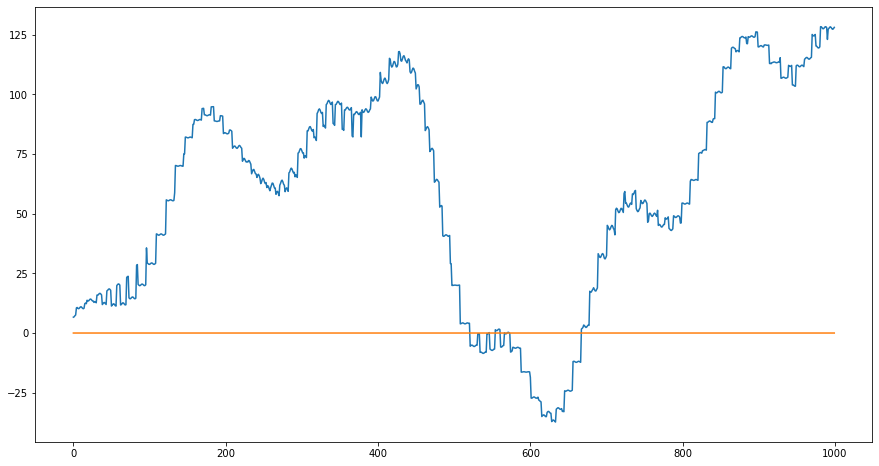

In [22]:
print(obs_cmb[0].tod)
print(obs_wn[0].tod)

plt.figure(figsize=(15,8))
plt.plot(obs_cmb[0].tod[0][:1000])
plt.plot(obs_wn[0].tod[0][:1000])

In [22]:
pointings = np.zeros((12, 1641600, 3))
pointings[:,:,:2] = obs_cmb[0].pointings
pointings[:,:,2]  = obs_cmb[0].psi

In [23]:
m_cmb_fg_1fpess = lbs.make_bin_map([obs_cmb[0],obs_fg[0],obs_1fpess[0]],
                                    nside,
                                    pointings = [pointings,pointings,pointings],
                                    do_covariance = False,
                                    output_map_in_galactic = True
                                    )
m_cmb = lbs.make_bin_map(obs_cmb[0],
                         nside,
                         pointings = pointings,
                         do_covariance = False,
                         output_map_in_galactic = True
                        )
m_fg = lbs.make_bin_map(obs_fg[0],
                        nside,
                        pointings = pointings,
                        do_covariance = False,
                        output_map_in_galactic = True
                        )
m_1fpess = lbs.make_bin_map(obs_1fpess[0],
                            nside,
                            pointings = pointings,
                            do_covariance = False,
                            output_map_in_galactic = True
                           )


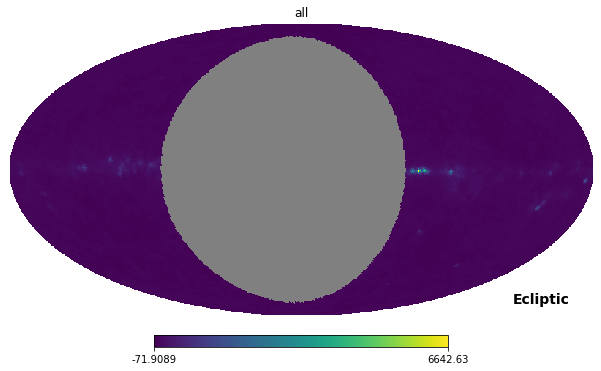

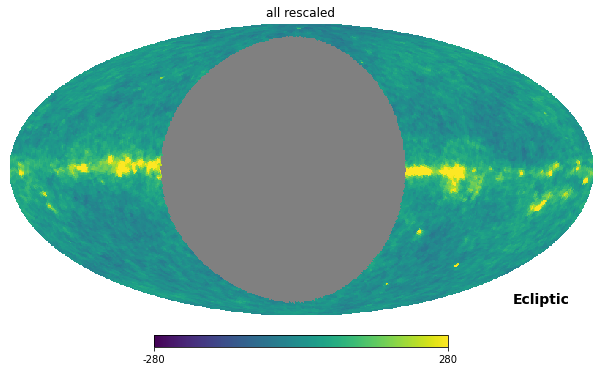

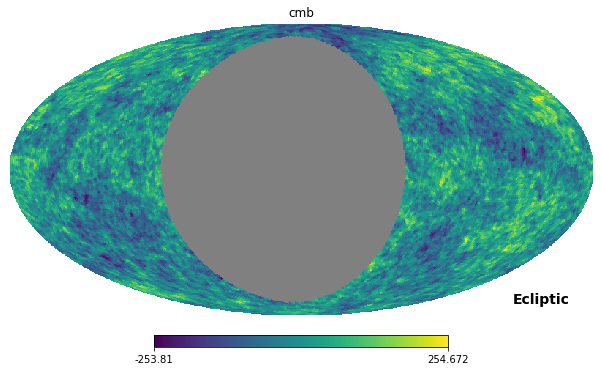

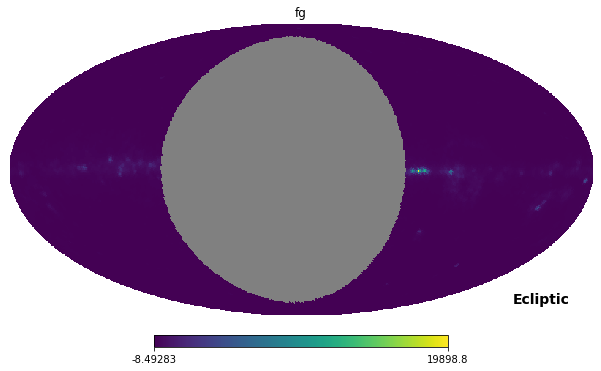

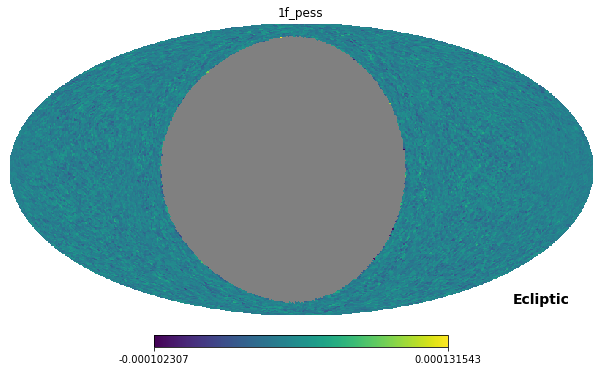

In [24]:
hp.mollview(m_cmb_fg_1fpess[0],coord=["G","E"],title='all')
hp.mollview(m_cmb_fg_1fpess[0],coord=["G","E"],min=-280,max=280,title='all rescaled')

hp.mollview(m_cmb[0],coord=["G","E"],title='cmb')
hp.mollview(m_fg[0],coord=["G","E"],title='fg')
hp.mollview(m_1fpess[0],coord=["G","E"],title='1f_pess')

# 1/f noise

In [5]:
one_over_f_pes = lbs.io.read_one_observation(rootdir+'nersc_home/lbs_outputs/obs_1_over_f_noise_pessimistic_rank0.hdf5')
one_over_f_rea = lbs.io.read_one_observation(rootdir+'nersc_home/lbs_outputs/obs_1_over_f_noise_realistic_rank0.hdf5')

/home/bortolami/anaconda3/lib/python3.7/site-packages/erfa/core.py:155: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  ErfaWarning)
/home/bortolami/anaconda3/lib/python3.7/site-packages/erfa/core.py:155: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  ErfaWarning)


In [6]:
print(one_over_f_pes.fknee_mhz)
print(one_over_f_rea.fknee_mhz)

print(len(one_over_f_pes.tod[0][:10]))

[100 100]
[30 30]
10


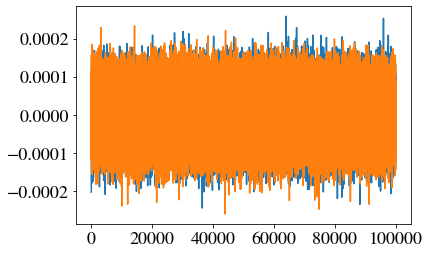

In [10]:
n_tod = 100000

x = np.arange(len(one_over_f_pes.tod[0][:n_tod]))
y = one_over_f_pes.tod[0][:n_tod]
plt.plot(x,y)

y = one_over_f_rea.tod[0][:n_tod]
plt.plot(x,y)
plt.show()

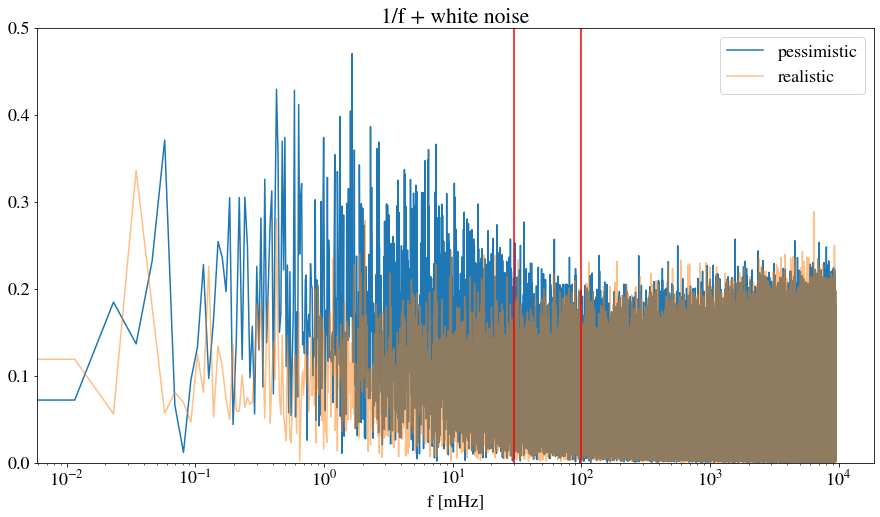

In [15]:
plt.figure(figsize=(15,8))

freqs = np.fft.fftfreq(one_over_f_pes.n_samples,1/one_over_f_pes.sampling_rate_hz)
ft_w_1_f_pes = np.fft.fft(one_over_f_pes.tod[0])
ft_w_1_f_rea = np.fft.fft(one_over_f_rea.tod[0])

id_fr = int(freqs.shape[0]/2.)
plt.plot(freqs[:id_fr]*1000,np.abs(ft_w_1_f_pes[:id_fr]),label='pessimistic')
plt.plot(freqs[:id_fr]*1000,np.abs(ft_w_1_f_rea[:id_fr]),label='realistic',alpha=0.5)

plt.axvline(30,color='red')
plt.axvline(100,color='red')
plt.legend()

plt.title('1/f + white noise')
plt.xscale('log')
#plt.yscale('log')
plt.ylim(0,0.5)
plt.xlabel('f [mHz]')

plt.show(0.1,1000)

# Output maps

In [ ]:
def get_filter(fknee_mhz,fmin_hz,alpha,sigma):
    fknee_hz_alpha = pow(fknee_mhz / 1000, alpha)
    fmin_hz_alpha = pow(fmin_hz, alpha)

    ft = np.ones(len(freqs))

    # Skip the first element, as it is the constant offset
    for i in range(1, len(ft)):
        f_hz_alpha = pow(abs(freqs[i]), alpha)
        ft[i] *= (
            np.sqrt((f_hz_alpha + fknee_hz_alpha) / (f_hz_alpha + fmin_hz_alpha))
            * sigma
        )
    ft[0] = 0
    return(ft)

fknee_mhz = 100
fmin_hz = 0.0001
alpha = 0.8
sigma = 1
ft1 = get_filter(fknee_mhz,fmin_hz,alpha,sigma)

fknee_mhz = 30
fmin_hz = 0.0001
alpha = 0.8
sigma = 1
ft2 = get_filter(fknee_mhz,fmin_hz,alpha,sigma)

fknee_mhz = 100
fmin_hz = 0.01
alpha = 0.8
sigma = 1
ft3 = get_filter(fknee_mhz,fmin_hz,alpha,sigma)

fknee_mhz = 100
fmin_hz = 0.0001
alpha = 0.6
sigma = 1
ft4 = get_filter(fknee_mhz,fmin_hz,alpha,sigma)

fknee_mhz = 100
fmin_hz = 0.0001
alpha = 0.8
sigma = 0.8
ft5 = get_filter(fknee_mhz,fmin_hz,alpha,sigma)

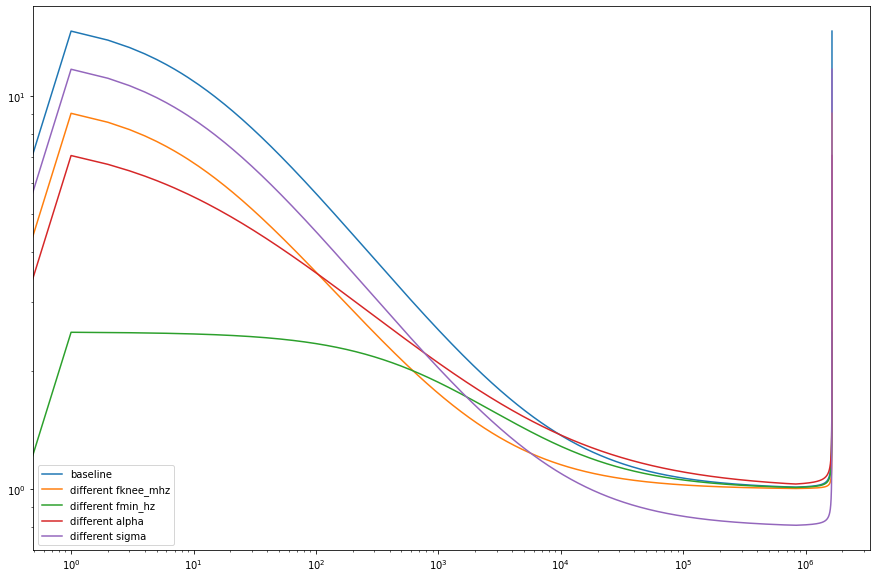

In [69]:
plt.figure(figsize=(15,10))

plt.plot(ft1,label='baseline')
plt.plot(ft2,label='different fknee_mhz')
plt.plot(ft3,label='different fmin_hz')
plt.plot(ft4,label='different alpha')
plt.plot(ft5,label='different sigma')

plt.loglog()
plt.legend()

plt.show()

# Other stuff